# Options basket, pytorch et réduction de variance

In [77]:
import math
import time
import os
import pickle
import numpy as np 
import scipy.stats as sps 
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_theme()
import pandas as pd
from tqdm import tqdm

from numpy.random import default_rng, SeedSequence
sq = SeedSequence()
seed = sq.entropy        # on sauve la graine pour reproduire les résultats
rng = default_rng(sq)

## Retour sur Monte Carlo avec erreur préscrite

Pour un échantillon $(X_i)_{1 \leq i \leq n}$ de taille $n$ l’estimateur
Monte Carlo se contruit à partir de l’estimation de la moyenne empirique
$\hat m_n$ et de l’estimation de la variance empirique $\hat \sigma^2_n$
définies par $$
  \hat m_n = \frac{1}{n} \sum_{i=1}^n X_i \quad \text{et} \quad 
  \hat \sigma_n^2 = \frac{n}{n-1} \big( \frac{1}{n} \sum_{i=1}^n X_i^2 - \hat m_n^2 \big) 
$$ La taille de l’intervalle de confiance de niveau $\alpha$

In [78]:
def monte_carlo_adaptive(sampling_function, epsilon: float, 
                         batch_size: int = 100000, 
                         proba: float = 0.95) -> dict:
    """
    Effectue une estimation Monte Carlo adaptative jusqu'à ce que l'intervalle
    de confiance de la moyenne soit inférieur à epsilon.

    Args:
    - sampling_function (callable): Une fonction qui produit des échantillons 
      de taille donnée en argument.
    - epsilon (float): La taille maximum tolérée pour l'IC.
    - proba (float): Niveau de confiance pour l'intervalle (défaut: 0.95).
    - batch_size (int): Taille du batch pour les simulations.

    Returns:
    - dict: Un dictionnaire contenant les valeurs suivantes :
        - "mean" (float): Moyenne de l'échantillon final.
        - "var" (float): Variance de l'échantillon final.
        - "ci_size" (float): Taille de l'intervalle de confiance.
        - "samples_size" (int): Nombre de tirages effectués.
        - "time (s)" (float): Temps d'execution en secondes.
    """
    alpha = 1 - proba
    quantile = sps.norm.ppf(1 - alpha / 2)

    sum_, sum2_, size_ = 0, 0, 0
    start = time.time()
    with tqdm(total=None, desc="Adaptive Monte Carlo") as pbar:
        while True:
            # Génération d'un nouveau batch d'échantillons
            samples = sampling_function(batch_size)
            sum_ += samples.sum().item()
            sum2_ += (samples**2).sum().item()
            size_ += batch_size

            mean = sum_ / size_
            var = size_ / (size_-1) * (sum2_ / size_ - mean**2)
            ci_size = 2 * quantile * math.sqrt(var / size_)
    
            # Mise à jour de tqdm avec la taille de l'IC actuelle
            pbar.set_postfix({"IC_size": ci_size, "mean": mean, "var": var})
            pbar.update(batch_size)

            if ci_size <= epsilon:
                break
    stop = time.time()
    return {
        "mean": mean,
        "var": var,
        "ci_size": ci_size,
        "samples_size": size_,
        "time (s)": stop-start,
    }

## Options basket: pricing Monte Carlo

Dans cette première partie on na fait pas de la programmation orientée
objet mais on s’en approche en rassemblant tous les paramètres dans un
dictionnaire.

> **Note**
>
> Il est conseillé d’éviter les variables globales (pour prendre de
> bonnes habitudes de programmation et réutiliser facilement son code),
> donc on va regrouper les différents paramètre dans un dictionnaire.

In [79]:
def model_bs(d, r, S0, sigma, correlation, T):
    """
    Initialise les paramètres du modèle multidimensionnel de Black-Scholes.

    Args:
    - d (int): Dimension, représentant le nombre d'actifs dans le panier.
    - r (float): Taux d'intérêt sans risque.
    - S0 (np.ndarray): Vecteur des prix initiaux des actifs, de taille (d,).
    - sigma (np.ndarray): Vecteur des volatilités des actifs, de taille (d,).
    - correlation (np.ndarray): Matrice de corrélation, de taille (d, d).
    - T (float): Maturité de l'option (temps jusqu'à l'échéance).

    Returns:
    - dict: Un dictionnaire contenant les paramètres du modèle.
    """
    return {
        "d": d,
        "r": r,
        "S0": S0,
        "sigma": sigma,
        "mu": r - 0.5 * sigma**2,
        "correlation": correlation,
        "correlation_cholesky": np.linalg.cholesky(correlation),
        "T": T,
        "actualization": math.exp(-r * T)
    }

d = 40
rho = 0.3
bs = model_bs(d=d, r=0.1, S0=np.full((d), 100), 
              sigma=np.full((d), 0.3), 
              correlation=np.full((d,d), rho) + (1-rho)*np.eye(d),
              T=1)

### Code `numpy`

On considère $d \ge 2$ actifs financiers dont la loi à l’instant $T > 0$
est modélisée par une loi log-normale c’est à dire $$
    \forall i \in \{1,\dots,d\}, \quad
    S^i_T = S^i_0 \exp\Bigl( \bigl(r-\frac{\sigma_i^2}{2}\bigr) T + \sigma_i \sqrt{T} \tilde G_i \Bigr)
$$ où le vecteur $(\tilde G_1,\dots, \tilde G_d)$ est gaussien centré de
matrice de covariance $\Sigma$ et les constantes $r > 0$, $\sigma_i > 0$
sont fixées. Il s’agit d’actifs financiers $(S^i_t)_{t \in [0,T]}$,
$1 \le i \le d$, modélisés par un processus de Black-Scholes
multidimensionnel. On introduit la matrice $L$ triangulaire inférieure
obtenue par la décomposition de Cholesky de la matrice
$\Sigma = L L^\top$.

A l’aide de cette matrice $L$, on définit la fonction
$\Phi:\mathbf{R}^d \to \mathbf{R}^d$ telle que $$
    (S^1_T, \dots, S^d_T) = \Phi(G_1, \dots, G_d) \quad \text{ou encore} \quad S^i_T = \Phi_i(G_1, \dots, G_d)
$$ où $(G_1, \dots, G_d) \sim \mathcal{N}(0, I_d)$ (l’égalité précédente
est à considérer en loi).

In [80]:
def phi(bs, Gn):
    mu_T = bs["mu"] * bs["T"]
    sig_T = bs["sigma"] * math.sqrt(bs["T"]) * bs["correlation_cholesky"] 
    ST = bs["S0"] * np.exp(mu_T + np.einsum('ij,pj->pi', sig_T, Gn))
    return ST

La fonction `phi` correspond au modèle financier choisi (ici
Black-Scholes) et doit être modifié si on change de modèle. Il est utile
d’écrire cette fonction comme transformation d’un vecteur
$(G_n)_{n=1,\dots,d}$ pour faciliter l’implémentation des méthodes de
réduction de variance.

La fonction suivante `sampling_payoffs` regroupe

-   la simulation du vecteur $(G_n)_{n=1,\dots,d}$ (en fait un nombre
    `size` de vecteurs de $\mathbf{R}^d$)
-   l’application du modèle via l’appel de `phi`
-   la transformation via la fonction payoff
    $g:\mathbf{R}^d \to \mathbf{R}$ $$
        g(S_T) = \Bigl( \frac{1}{d} \sum_{i=1}^d S^i_T - K \Big)_+
    $$

In [81]:
def sampling_payoffs(K, size, bs, rng): 
    Gn = rng.standard_normal((size, bs["d"]))
    samples = phi(bs, Gn)
    payoffs = np.maximum(np.mean(samples, axis=1)-K, 0.) 
    return bs["actualization"] * payoffs

On regroupe dans une fonction `run` l’appel de la fonction
`monte_carlo_adaptive` pour différentes valeurs de
$K \in \{80,90,100,110,120\}$. La fonction prend comme argument la
fonction `sampling_payoffs` (et ses arguments) car c’est la fonction qui
sera modifiée dans la suite.

In [82]:
def run(name, function, epsilon, batch_size, **kwargs): 

    result = {} 
    for K in [80, 90, 100, 110, 120]:
      result[K] = monte_carlo_adaptive(
          lambda size: function(K, size, **kwargs), 
          epsilon=epsilon, 
          batch_size=batch_size)
    result_df = pd.DataFrame(result).T
    result_df["K"] = result_df.index
    result_df["method"] = name 

    return result_df

On vérifie que le temps d’execution est proportionnel au nombre de
d’échantillons utilisé dans l’estimateur Monte Carlo.

> **Note**
>
> Avant de lancer des gros calculs, pensez à vérifier que votre
> algorithme se comporte comme attendu. Ici l’estimateur Monte Carlo est
> linéaire donc le temps d’execution doit être proportionnel au au
> nombre de simulations. Si ce n’est pas le cas il y a un problème
> d’implémentation ou de gestion de la mémoire)

In [83]:
epsilon = 0.01
batch_size = int(1e6)
result_numpy = run("numpy", sampling_payoffs, epsilon=epsilon, 
    batch_size=batch_size, bs=bs, rng=rng)
result_numpy

Adaptive Monte Carlo: 44000000it [00:36, 1189714.25it/s, IC_size=0.0099, mean=27.8, var=281]
Adaptive Monte Carlo: 39000000it [00:32, 1184472.25it/s, IC_size=0.00992, mean=19.4, var=250]
Adaptive Monte Carlo: 30000000it [00:25, 1195204.81it/s, IC_size=0.00991, mean=12.3, var=192]
Adaptive Monte Carlo: 19000000it [00:15, 1198813.95it/s, IC_size=0.00996, mean=6.96, var=123]
Adaptive Monte Carlo: 11000000it [00:09, 1181993.16it/s, IC_size=0.0096, mean=3.56, var=66] 


,mean,var,ci_size,samples_size,time (s),K,method
80,27.766534,280.616704,0.009899,44000000.0,36.985466,80,numpy
90,19.391415,249.953203,0.009924,39000000.0,32.926979,90,numpy
100,12.264333,191.765775,0.009911,30000000.0,25.101238,100,numpy
110,6.964153,122.694511,0.009961,19000000.0,15.849783,110,numpy
120,3.555150,66.036318,0.009604,11000000.0,9.307451,120,numpy


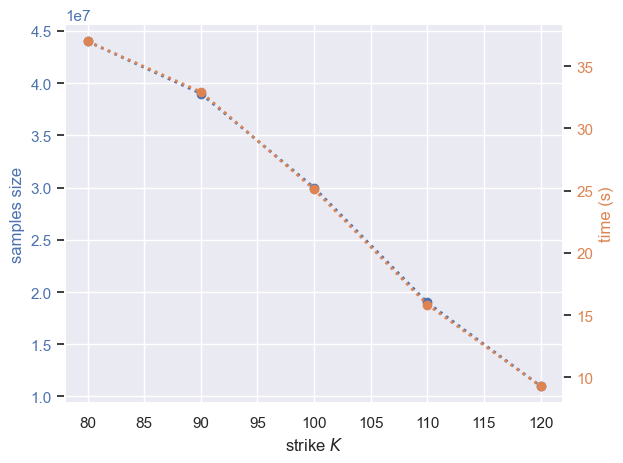

In [84]:
fig, ax1 = plt.subplots(layout="tight")

color = 'C0'
ax1.set_xlabel(r'strike $K$')
ax1.set_ylabel('samples size', color=color)
ax1.plot(result_numpy["K"], result_numpy["samples_size"], 
         marker="o", ls=':', lw=2, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() 

color = 'C1'
ax2.set_ylabel('time (s)', color=color) 
ax2.plot(result_numpy["K"], result_numpy["time (s)"], 
         marker="o", ls=':', lw=2, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False);

### Passage du code en `pytorch`

PyTorch est une bibliothèque open-source de calcul scientifique et
d’apprentissage automatique largement utilisée dans la recherche et
l’industrie. Elle est particulièrement conçue pour le développement et
l’entraînement de modèles d’apprentissage profond, mais elle offre
également des outils puissants pour la simulation et les probabilités
numériques.

-   PyTorch repose sur la manipulation de tenseurs, des structures
    multidimensionnelles similaires à des matrices, qui permettent des
    opérations rapides et efficaces sur de grandes quantités de données.
-   PyTorch peut exécuter des calculs sur GPU, offrant ainsi des
    performances considérablement améliorées pour les tâches exigeantes
    en ressources.
-   Différentiation automatique (Autograd): L’un des points forts de
    PyTorch est son système de différenciation automatique, qui
    simplifie le calcul des gradients pour optimiser des fonctions
    complexes. Cela est essentiel pour l’entraînement des modèles
    d’apprentissage profond.

Pour passer d’un code NumPy à un code PyTorch il faut remplacer les
objets `np.ndarray` par des objets `torch.tensor`. Une nouveauté est la
notion de `device`.

> **Important**
>
> En PyTorch, un device désigne l’endroit où les calculs et les données
> sont stockés et exécutés. En pratique il y a essentiellement 2 types
> de device:
>
> -   CPU (Central Processing Unit) : l’unité de traitement standard de
>     l’ordinateur.
> -   GPU (Graphics Processing Unit) : une unité de traitement
>     spécialisée, capable d’exécuter des opérations massivement
>     parallèles.

Le type de données stockées dans le `torch.tensor` doit être
**compatible avec le device utilisé**. Dans la suite on utilise le type
`torch.float32` pour que le code suivant puisse être executé sur un GPU
Nvidia d’il y a quelques années ou sur le GPU intégré de la puce ARM
d’apple.

In [85]:
import torch
dtype = torch.float32
device = torch.device("cpu")
rng_torch = torch.Generator(device=device)

bs_torch = { 
    key: torch.tensor(item, dtype=dtype, device=device) 
        if type(item) is np.ndarray else item 
        for key, item in bs.items() 
}

Il faut remplacer la fonction `phi` par la version `pytorch` tout
simplement en remplaçant les appels `np.exp` et `np.einsum` par les
versions `torch.exp` et `torch.einsum`.

In [86]:
def phi_torch(bs, Gn):
    mu_T = bs["mu"] * bs["T"]
    sig_T = bs["sigma"] * math.sqrt(bs["T"]) * bs["correlation_cholesky"] 
    ST = bs["S0"] * torch.exp(mu_T + torch.einsum('ij,pj->pi', sig_T, Gn)) 
    return ST

De même on modifie la fonction `sampling_payoffs`.

In [87]:
def sampling_payoffs_torch(K, size, bs, device, rng): 
    Gn = torch.randn((size, bs["d"]), dtype=dtype, 
                     device=device, generator=rng)
    samples = phi_torch(bs, Gn)
    payoffs = torch.nn.functional.relu(torch.mean(samples, axis=1) - K)
    #payoffs = torch.maximum(torch.mean(samples, axis=1) - K, 
    #                        torch.full((size,), 0.0, device=device)) 
    return bs["actualization"] * payoffs

> **Warning**
>
> Dans certains cas, la fonction `pytorch` a le même nom que la fonction
> `numpy` mais les appels autorisés peuvent être différents par exemple
> la fonction `np.maximum` peut comparer un objet `np.ndarray` et un
> scalaire alors que la version pytorch `torch.maximum` fair la
> comparaison uniquement entre 2 objets `torch.tensor`.
>
> Une alternative ici est d’utiliser la fonction `ReLU` (qui est
> simplement la fonction partie positive) dans `torch.nn.functional`.

In [88]:
result_torch_cpu = run("torch_cpu", sampling_payoffs_torch, epsilon=epsilon, 
    batch_size=batch_size, bs=bs_torch, device=device, rng=rng_torch)
result_torch_cpu

Adaptive Monte Carlo: 44000000it [00:06, 6375267.95it/s, IC_size=0.0099, mean=27.8, var=281]
Adaptive Monte Carlo: 39000000it [00:06, 6327924.80it/s, IC_size=0.00993, mean=19.4, var=250]
Adaptive Monte Carlo: 30000000it [00:04, 6461682.90it/s, IC_size=0.00991, mean=12.3, var=192]
Adaptive Monte Carlo: 19000000it [00:02, 6461918.87it/s, IC_size=0.00996, mean=6.96, var=123]
Adaptive Monte Carlo: 11000000it [00:01, 6525178.40it/s, IC_size=0.0096, mean=3.55, var=65.9]


,mean,var,ci_size,samples_size,time (s),K,method
80,27.769639,280.706259,0.009901,44000000.0,6.903001,80,torch_cpu
90,19.399929,250.090608,0.009926,39000000.0,6.164299,90,torch_cpu
100,12.259754,191.608462,0.009907,30000000.0,4.644058,100,torch_cpu
110,6.963109,122.697598,0.009961,19000000.0,2.941267,110,torch_cpu
120,3.552353,65.912922,0.009595,11000000.0,1.687111,120,torch_cpu


> **Note**
>
> On remarque que le code `pytorch` sur CPU est 2 fois plus rapide que
> le code `numpy`. C’est étonnant car les deux codes tournent sur le CPU
> et devraient donc donner des résultats équivalents. Sur votre machine
> vous avez peut-être des temps comparables. Les différences qui peuvent
> expliquer les temps de calculs sont
>
> -   le générateur de nombres pseudo-aléatoires (différence entre `rng`
>     et `rng_torch`)
> -   le type utilisé ici `dtype` est sur 32 bits alors que le type
>     `numpy` est 64 bits

### Changement de `device`

Cette section ne peut s’executer que si vous avec un ordinateur Apple
récent (puce ARM). Il est facilement executable sur un carte graphique
Nvidia en changeant le device, par exemple

In [89]:
device = torch.device("cuda")

> **Note**
>
> Le device `mps` dans PyTorch fait référence à l’utilisation du backend
> Metal Performance Shaders (MPS), qui est une technologie développée
> par Apple. Elle permet d’exécuter des calculs tensoriels sur les GPU
> des appareils Apple, comme les Mac équipés de processeurs Apple
> Silicon (M1, M2, etc.) ou d’autres GPU compatibles Metal. C’est une
> alternative à CUDA mais encore partielle (toutes les fonctionnalités
> PyTorch ne sont pas encore être entièrement prises en charge pour MPS)
> et les performances sont inférieures à celles des GPU NVIDIA haut de
> gamme utilisant CUDA.

Dans le code précédent on doit modifié l’objet `bs_torch` pour déplacer
les données des `torch.tensor` vers le device utilisé. Les fonctions
`phi_torc` et `sampling_payoffs_torch` n’ont pas besoin d’être
réécrites, il suffit de changer les arguments!

In [90]:
#device = torch.device("mps")
rng_torch = torch.Generator(device=device)
bs_torch = { 
    key: torch.tensor(item, dtype=dtype, device=device) 
        if type(item) is np.ndarray else item 
        for key, item in bs.items() 
}

In [91]:
result_torch_mps = run("torch_cuda", sampling_payoffs_torch, epsilon=epsilon, 
    batch_size=batch_size, bs=bs_torch, device=device, rng=rng_torch)
result_torch_mps

Adaptive Monte Carlo: 44000000it [00:00, 60674099.91it/s, IC_size=0.0099, mean=27.8, var=281]
Adaptive Monte Carlo: 39000000it [00:00, 114762243.72it/s, IC_size=0.00993, mean=19.4, var=250]
Adaptive Monte Carlo: 30000000it [00:00, 129859973.58it/s, IC_size=0.00991, mean=12.3, var=192]
Adaptive Monte Carlo: 19000000it [00:00, 138765738.56it/s, IC_size=0.00997, mean=6.97, var=123]
Adaptive Monte Carlo: 11000000it [00:00, 139111204.92it/s, IC_size=0.0096, mean=3.55, var=66] 


,mean,var,ci_size,samples_size,time (s),K,method
80,27.767202,280.529912,0.009898,44000000.0,0.726342,80,torch_cuda
90,19.395393,250.044280,0.009926,39000000.0,0.340875,90,torch_cuda
100,12.265392,191.688457,0.009909,30000000.0,0.232198,100,torch_cuda
110,6.965617,122.798718,0.009965,19000000.0,0.137718,110,torch_cuda
120,3.552220,66.027713,0.009604,11000000.0,0.080104,120,torch_cuda


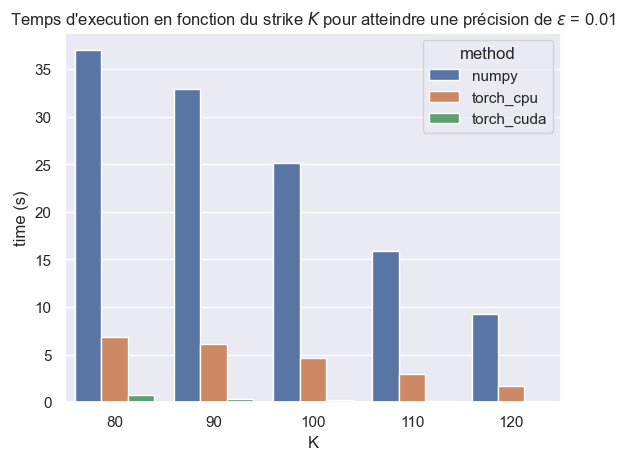

In [92]:
result = pd.concat([ result_numpy, result_torch_cpu, result_torch_mps ])
ax = sns.barplot(data=result, x="K", y="time (s)", hue="method")
ax.set_title(fr"Temps d'execution en fonction du strike $K$ pour " + 
             fr"atteindre une précision de $\epsilon$ = {epsilon}");

## Méthodes de réduction de variance

On rappelle que le modèle est codé à travers la fonction `phi`. Cette
fonction ne sera pas modifiée dans la suite. Le payoff est donné par une
fonction $g:\mathbf{R}^d \to \mathbf{R}_+$ et le code est fait dans la
fonction `sampling_payoffs`. On va implémenter les méthodes des
réduction de variance vues en cours en modifiant la fonction
`sampling_payoffs`.

### Variables antithétiques

Pour utiliser les variables antithétiques on utilise le fait que
$G \sim \mathcal{N}(0, \operatorname{Id}_d)$ et $-G$ ont même loi et
donc que $$
  \mathbf{E} \big[ (g \circ \Phi)(G) \big] = \frac{1}{2} 
  \mathbf{E} \big[ (g \circ \Phi)(G) + (g \circ \Phi)(-G) \big]. 
$$ Cela suggère d’utiliser la représentation de droite pour écrire un
estimateur Monte Carlo de la forme $$
  \tilde I_n = \frac{1}{2 n} \sum_{i=1}^n \big( g \circ \Phi(G_i) + g \circ \Phi(-G_i) \big),
$$ où $(G_i)_{i \ge 1}$ est une suite *i.i.d.* de loi
$\mathcal{N}(0, \operatorname{Id}_d)$.

Voici le code modifié pour implémenter les variables antithétiques.

In [93]:
def sampling_payoffs_antithetic(K, size, bs, rng): 
    Gn = rng.standard_normal((size, bs["d"]))
    payoffs_1 = np.maximum(np.mean(phi(bs, Gn), axis=1) - K, 0) 
    payoffs_2 = np.maximum(np.mean(phi(bs, -Gn), axis=1) - K, 0) 
    payoffs = 0.5 * (payoffs_1 + payoffs_2)
    return bs["actualization"] * payoffs

> **Warning**
>
> Dans la suite comme le nombre d’échantillons va diminuer (car on
> utilise des méthodes de réduction de variance) on change le
> `batch_size` dans le Monte Carlo adaptatif: on passe de $1\,000\,000$
> à $100\,000$.

In [94]:
batch_size = int(1e5)
result_antithetic = run("antithetic", sampling_payoffs_antithetic, 
    epsilon=epsilon, batch_size=batch_size, bs=bs, rng=rng)
result_antithetic

Adaptive Monte Carlo: 1200000it [00:01, 696174.60it/s, IC_size=0.00984, mean=27.8, var=7.57]
Adaptive Monte Carlo: 2500000it [00:03, 687148.39it/s, IC_size=0.00983, mean=19.4, var=15.7]
Adaptive Monte Carlo: 4600000it [00:06, 684916.69it/s, IC_size=0.00992, mean=12.3, var=29.5]
Adaptive Monte Carlo: 5700000it [00:08, 681781.83it/s, IC_size=0.01, mean=6.96, var=37.1]  
Adaptive Monte Carlo: 4100000it [00:06, 680311.51it/s, IC_size=0.00999, mean=3.55, var=26.6]


,mean,var,ci_size,samples_size,time (s),K,method
80,27.763688,7.565365,0.009842,1200000.0,1.724977,80,antithetic
90,19.399543,15.724141,0.009831,2500000.0,3.639759,90,antithetic
100,12.264132,29.457681,0.009920,4600000.0,6.717031,100,antithetic
110,6.962649,37.074154,0.009997,5700000.0,8.361540,110,antithetic
120,3.548517,26.633407,0.009991,4100000.0,6.027799,120,antithetic


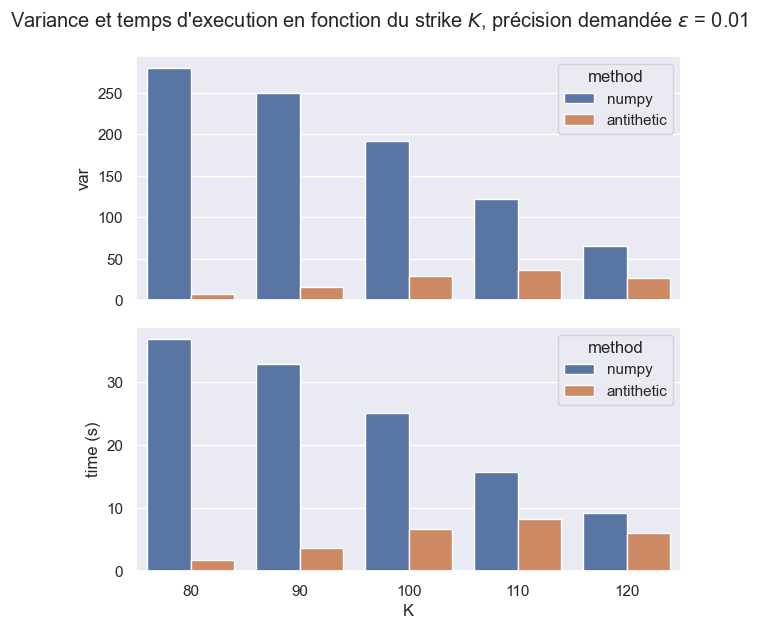

In [95]:
result = pd.concat([ result_numpy, result_antithetic ])
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6.4,6.4), 
                               sharex=True, layout="tight")
sns.barplot(data=result, x="K", y="var", hue="method", ax=ax1)
sns.barplot(data=result, x="K", y="time (s)", hue="method", ax=ax2)
fig.suptitle(fr"Variance et temps d'execution en fonction du strike $K$, "
             +fr"précision demandée $\epsilon$ = {epsilon}");

#### Passage en `pytorch`

Pas de difficulté particulière ici, si suffit de modifier la fonction
`sampling_payoffs_torch` pour évaluer 2 fois $g \circ \Phi$ (via `relu`,
`torch.mean` et `phi_torch`).

In [112]:
from torch.nn.functional import relu 
def sampling_payoffs_torch_antithetic(K, size, bs, device, rng): 
    Gn = torch.randn((size, bs["d"]), dtype=dtype, 
                     device=device, generator=rng)
    #samples = phi_torch(bs, Gn)
    payoffs_1 = relu(torch.mean(phi_torch(bs, Gn), axis=1) - K)
    payoffs_2 = relu(torch.mean(phi_torch(bs, -Gn), axis=1) - K)
    payoffs = 0.5 * (payoffs_1 + payoffs_2)
    return bs["actualization"] * payoffs

In [113]:
result_antithetic_mps = run("antithetic_cuda", 
    sampling_payoffs_torch_antithetic, epsilon=epsilon, 
    batch_size=batch_size, bs=bs_torch, device=device, rng=rng_torch)
result_antithetic_mps

Adaptive Monte Carlo: 1180000it [00:00, 9147256.66it/s, IC_size=0.00993, mean=27.8, var=7.57]
Adaptive Monte Carlo: 2420000it [00:00, 11499575.92it/s, IC_size=0.00997, mean=19.4, var=15.7]
Adaptive Monte Carlo: 4540000it [00:00, 15031852.39it/s, IC_size=0.00998, mean=12.3, var=29.4]
Adaptive Monte Carlo: 5720000it [00:00, 18833446.41it/s, IC_size=0.00998, mean=6.96, var=37.1]
Adaptive Monte Carlo: 4120000it [00:00, 19881923.06it/s, IC_size=0.00998, mean=3.55, var=26.7]


,mean,var,ci_size,samples_size,time (s),K,method
80,27.765727,7.574819,0.009932,1180000.0,0.132232,80,antithetic_cuda
90,19.393324,15.652379,0.009969,2420000.0,0.211281,90,antithetic_cuda
100,12.263614,29.434453,0.009981,4540000.0,0.303142,100,antithetic_cuda
110,6.962103,37.108212,0.009984,5720000.0,0.304725,110,antithetic_cuda
120,3.553585,26.681542,0.009976,4120000.0,0.208037,120,antithetic_cuda


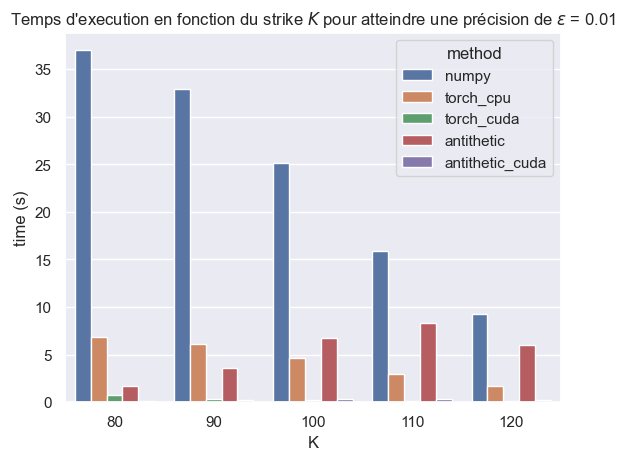

In [114]:
result = pd.concat([ result_numpy, result_torch_cpu, result_torch_mps, 
  result_antithetic, result_antithetic_mps ])
ax = sns.barplot(data=result, x="K", y="time (s)", hue="method")
ax.set_title(fr"Temps d'execution en fonction du strike $K$ pour " + 
             fr"atteindre une précision de $\epsilon$ = {epsilon}");

### Variable de contrôle

On rappelle que le prix d’un Call dans un modèle de Black-Scholes en
dimension 1, le prix est donnée par une formule fermée. Pour une option
Basket (en dimension $d \ge 2$) on approche le prix par Monte Carlo mais
on peut utiliser des approximations pour trouver un produit
unidimensionnel proche du produit Basket. Ces approximations servent de
variables de contrôles: **on ne rajoute pas une erreur, on retire de la
variance**…

On rappelle que, en posant $\mu_i = r - \frac{1}{2}\sigma_i^2$, $$
    X = \biggl(\frac{1}{d} \sum_{i=1}^d S^i_0 e^{\mu_i T + \sigma_i \sqrt{T} \tilde G_i}  - K\biggr)_+
$$ et en introduisant $a^i_0 = \frac{S^i_0}{\sum_{j=1}^d S^j_0}$ (t.q.
$\sum a^i_0 = 1$) et $\bar S_0 = \frac{1}{d} \sum_{i=1}^d S^i_0$ on a $$
    X = \biggl(\bar S_0 \sum_{i=1}^d a^i_0 e^{\mu_i T + \sigma_i \sqrt{T} \tilde G_i}  - K\biggr)_+.
$$ La variable de contrôle proposée est obtenue en échangeant
l’exponentielle et la moyenne pondérée par les poids
$\big(a^i_0\big)_{i=1,\dots,d}$: $$
    Y = \bigl(\bar S_0 e^Z  - K\bigr)_+
    \quad \text{avec} \quad 
    Z = \sum_{i=1}^d a^i_0 \big(\mu_i T + \sigma_i \sqrt{T} \tilde G_i\big) 
$$ La variable aléatoire $Z$ suit une loi gaussienne
$Z \sim \mathcal{N}(m T, s^2 T)$ avec $$
    m = \sum_{i=1}^d a^i_0 \mu_i
    \quad \text{et} \quad
    s^2 = \sum_{i=1}^d \Big( \sum_{j=1}^d a^i_0 \sigma_i L_{ij} \Big)^2. 
$$ Ainsi l’espérance de la variable de contrôle $Y$ est connue par la
formule de Black-Scholes, car elle correspond au prix d’un call de
strike $K$ d’un actif Black-Scholes de dimension 1, de valeur initiale
$\bar S_0$, de taux $\rho = m+\frac{1}{2} s^2$ et de volatilité $s$ (à
un facteur d’actualisation près… attention à ça). On a donc $$
    e^{-\rho T} \mathbf{E} \big[ Y \big] = P_{\text{BS}}\big(\bar S_0, \rho, s, T, K\big),
$$ où $$
    P_{\text{BS}}\big(x, r, \sigma, T, K\big) = x F_{\mathcal{N}(0,1)}(d_1) - K e^{-r T} F_{\mathcal{N}(0,1)}(d_2),
$$ avec $F_{\mathcal{N}(0,1)}$ est la fonction de répartition de la loi
normale centrée réduite et la notation $$
    d_1 = \frac{1}{\sigma \sqrt{T}} \Big( \log\big( \frac{x}{K} \big) 
    + \big(r + \frac{\sigma^2}{2}\big) T \Big)
    \quad \text{et} \quad
    d_2 = d_1 - \sigma \sqrt{T}
$$

In [99]:
def black_scholes_call(S0: float, K: float, T: float, 
                       r: float, sigma: float) -> float:
    """
    Calcule le prix d'un Call européen dans le modèle de Black-Scholes.

    Args:
    - S0 (float): Prix actuel de l'actif sous-jacent.
    - K (float): Prix d'exercice du Call.
    - T (float): Temps jusqu'à l'échéance en années.
    - r (float): Taux d'intérêt sans risque.
    - sigma (float): Volatilité du sous-jacent.

    Returns:
    - float: Prix du Call européen.
    """
    # Calcul des paramètres d1 et d2
    d1 = (math.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    
    # Calcul du prix du Call
    call_price = S0*sps.norm.cdf(d1) - K*math.exp(-r*T)*sps.norm.cdf(d2)
    return call_price

> **Note**
>
> On code une fonction `payoffs_control` qui renvoie des réalisation de
> la variable de contrôle centrée $\tilde Y = Y - \mathbf{E}[Y]$. Il est
> important de noter que
>
> -   l’espérance est calculée en utilisant la formule fermée obtenue
>     car $Z \sim \mathcal{N}(m T, s^2 T)$
> -   les réalisations de $Y$ (et donc de $Z$) sont obtenues par
>     transformation de $G$ et donc la fonction `payoffs_control` doit
>     prendre comme argument l’objet `Gn`

In [100]:
def payoffs_control(bs, K, Gn): 
    weight = bs["S0"] / bs["S0"].sum()
    m = (weight * bs["mu"]).sum()
    s2 = (((weight * bs["sigma"]) @ bs["correlation_cholesky"])**2).sum()
    rho = m + 0.5*s2

    mu_T = bs["mu"] * bs["T"]
    sig_T = bs["sigma"] * math.sqrt(bs["T"]) * bs["correlation_cholesky"] 
    Z = np.sum(weight * (mu_T + np.einsum('ij,pj->pi', sig_T, Gn)), axis=1)
    Y = np.maximum(bs["S0"].mean() * np.exp(Z) - K, 0)
    Y_mean = np.exp(rho*bs["T"]) * \
        black_scholes_call(bs["S0"].mean(), K, bs["T"], 
                           r=rho, sigma=math.sqrt(s2))
    return Y - Y_mean

Etant donné cette variable aléatoire
$\tilde Y = Y - \mathbf{E}[Y]  = \psi(G)$ centrée, l’estimateur Monte
Carlo s’écrit $$
  \bar I_n = \frac{1}{n} \sum_{i=1}^n \big( (g \circ \Phi)(G_i) - \psi(G_i) \big).
$$

In [101]:
def sampling_payoffs_control_variate(K, size, bs, rng): 
    Gn = rng.standard_normal((size, bs["d"]))
    payoffs_X = np.maximum(np.mean(phi(bs, Gn), axis=1) - K, 0) 
    payoffs_Y = payoffs_control(bs, K, Gn)
    payoffs = payoffs_X - payoffs_Y
    return bs["actualization"] * payoffs

> **Warning**
>
> On réduit encore le `batch_size` et on passe à $20\,000$.

In [102]:
batch_size = 20000
result_varcont = run("var_cont", 
    sampling_payoffs_control_variate, epsilon=epsilon, 
    batch_size=batch_size, bs=bs, rng=rng)
result_varcont

Adaptive Monte Carlo: 180000it [00:00, 793527.46it/s, IC_size=0.00961, mean=27.8, var=1.08]
Adaptive Monte Carlo: 300000it [00:00, 766177.62it/s, IC_size=0.00972, mean=19.4, var=1.85]
Adaptive Monte Carlo: 440000it [00:00, 784494.61it/s, IC_size=0.00996, mean=12.3, var=2.84]
Adaptive Monte Carlo: 500000it [00:00, 787215.67it/s, IC_size=0.00998, mean=6.96, var=3.24]
Adaptive Monte Carlo: 420000it [00:00, 796634.97it/s, IC_size=0.00998, mean=3.56, var=2.72]


,mean,var,ci_size,samples_size,time (s),K,method
80,27.767146,1.080913,0.009606,180000.0,0.227993,80,var_cont
90,19.392709,1.846307,0.009725,300000.0,0.392570,90,var_cont
100,12.268541,2.838352,0.009956,440000.0,0.561966,100,var_cont
110,6.964850,3.243183,0.009983,500000.0,0.636577,110,var_cont
120,3.557704,2.724161,0.009983,420000.0,0.528792,120,var_cont


#### Version `pytorch`

In [103]:
def payoffs_control_torch(bs, K, Gn): #, S0, mu, sigma, sq_correl, maturity, strike):
    weight = bs["S0"] / bs["S0"].sum()
    m = (weight * bs["mu"]).sum().item()
    s2 = (((weight * bs["sigma"]) @\
            bs["correlation_cholesky"])**2).sum().item()
    rho = m + 0.5*s2

    mu_T = bs["mu"] * bs["T"]
    sig_T = bs["sigma"] * math.sqrt(bs["T"]) * bs["correlation_cholesky"] 
    Z = torch.sum(weight*(mu_T+torch.einsum('ij,pj->pi', sig_T, Gn)), axis=1)
    Y = relu(bs["S0"].mean() * torch.exp(Z) - K)
    Y_mean = math.exp(rho*bs["T"]) * \
        black_scholes_call(bs["S0"].mean().item(), K, bs["T"], 
                           r=rho, sigma=math.sqrt(s2))
    return Y - Y_mean

In [104]:
def sampling_payoffs_control_variate_torch(K, size, bs, device, rng): 
    Gn = torch.randn((size, bs["d"]), dtype=dtype, 
                     device=device, generator=rng)
    payoffs_X = relu(torch.mean(phi_torch(bs, Gn), axis=1) - K) 
    payoffs_Y = payoffs_control_torch(bs, K, Gn)
    payoffs = payoffs_X - payoffs_Y
    return bs["actualization"] * payoffs

In [105]:
result_varcont_mps = run("var_cont_cuda", 
    sampling_payoffs_control_variate_torch, epsilon=epsilon, 
    batch_size=batch_size, bs=bs_torch, device=device, rng=rng_torch)
result_varcont_mps

Adaptive Monte Carlo: 180000it [00:00, 9847838.88it/s, IC_size=0.00959, mean=27.8, var=1.08]
Adaptive Monte Carlo: 300000it [00:00, 10241666.94it/s, IC_size=0.00975, mean=19.4, var=1.85]
Adaptive Monte Carlo: 440000it [00:00, 10261123.03it/s, IC_size=0.00996, mean=12.3, var=2.84]
Adaptive Monte Carlo: 500000it [00:00, 9502489.86it/s, IC_size=0.00998, mean=6.96, var=3.24]
Adaptive Monte Carlo: 420000it [00:00, 10241786.03it/s, IC_size=0.00999, mean=3.56, var=2.73]


,mean,var,ci_size,samples_size,time (s),K,method
80,27.768241,1.076860,0.009588,180000.0,0.019557,80,var_cont_cuda
90,19.393873,1.854623,0.009746,300000.0,0.030391,90,var_cont_cuda
100,12.262587,2.838412,0.009956,440000.0,0.043680,100,var_cont_cuda
110,6.963644,3.239082,0.009977,500000.0,0.053451,110,var_cont_cuda
120,3.558166,2.727846,0.009990,420000.0,0.041741,120,var_cont_cuda


#### Variable de contôle optimale

Lorsqu’on travaille avec une variable de contrôle centrée $\tilde Y$, la
formule pour obtenir la combinaison linéaire entre le payoff $X$ et la
variable de contrôle $\tilde Y$ se simplifie en $$
  \lambda^* = \frac{\mathbf{E}\big[X \tilde Y]}{\mathbf{E}[\tilde Y^2]}.
$$ On rappelle que c’est le paramètre $\lambda^* \in \mathbf{R}$
solution de $$
  \lambda^* = \operatorname{argmin}_{\mathbf{R}} \operatorname{var}(X - \lambda \tilde Y).
$$ Ainsi on peut écrire un estimateur de $\lambda^*$ comme le ratio $$
  \lambda_n = \frac{\sum_{i=1}^n X_i \tilde Y_i}{\sum_{i=1}^n \tilde Y_i^2}
$$

In [106]:
def sampling_payoffs_control_variate_opt(K, size, bs, rng): 
    Gn = rng.standard_normal((size, bs["d"]))
    payoffs_X = np.maximum(np.mean(phi(bs, Gn), axis=1) - K, 0) 
    payoffs_Y = payoffs_control(bs, K, Gn)

    cntxt["lambda_numerator"] += (payoffs_X * payoffs_Y).sum() 
    cntxt["lambda_denominator"] += (payoffs_Y**2).sum() 
    cntxt["lambda"] = cntxt["lambda_numerator"] / cntxt["lambda_denominator"]

    payoffs = payoffs_X - cntxt["lambda"] * payoffs_Y
    return bs["actualization"] * payoffs

> **Warning**
>
> Ici on utilise une variable `cntxt` (un dictionnaire) pour stocker les
> quantités $\sum_{i=1}^n X_i \tilde Y_i$ et $\sum_{i=1}^n \tilde Y_i^2$
> qui sont mis à jour à chaque itération de la fonction
> `monte_carlo_adaptive`. Cette variable doit être initialisée avant le
> premier appel de `sampling_payoffs_control_variate_opt`, il faut donc
> adapter la fonction `run`.

In [107]:
name = "var_cont_opt"
function = sampling_payoffs_control_variate_opt

result = {} 
for K in [80, 90, 100, 110, 120]:
    cntxt = { "lambda_numerator": 0., "lambda_denominator": 1e-7 }
    result[K] = monte_carlo_adaptive(
        lambda size: function(K, size, bs, rng), 
        epsilon=epsilon, 
        batch_size=batch_size)
    result[K]["lambda"] = cntxt["lambda"]
result_df = pd.DataFrame(result).T
result_df["K"] = result_df.index
result_df["method"] = name 

result_varcont_opt = result_df
result_varcont_opt

Adaptive Monte Carlo: 120000it [00:00, 769806.58it/s, IC_size=0.00924, mean=27.8, var=0.667]
Adaptive Monte Carlo: 180000it [00:00, 784590.66it/s, IC_size=0.00963, mean=19.4, var=1.09]
Adaptive Monte Carlo: 240000it [00:00, 792289.37it/s, IC_size=0.00984, mean=12.3, var=1.51]
Adaptive Monte Carlo: 260000it [00:00, 790053.14it/s, IC_size=0.00983, mean=6.97, var=1.64]
Adaptive Monte Carlo: 220000it [00:00, 792340.34it/s, IC_size=0.0097, mean=3.56, var=1.35]


,mean,var,ci_size,samples_size,time (s),lambda,K,method
80,27.768880,0.667401,0.009244,120000.0,0.157157,1.038273,80,var_cont_opt
90,19.392490,1.085898,0.009628,180000.0,0.230559,1.062720,90,var_cont_opt
100,12.264128,1.513434,0.009844,240000.0,0.304000,1.090117,100,var_cont_opt
110,6.966865,1.636613,0.009835,260000.0,0.330056,1.128270,110,var_cont_opt
120,3.555140,1.345922,0.009696,220000.0,0.278473,1.170608,120,var_cont_opt


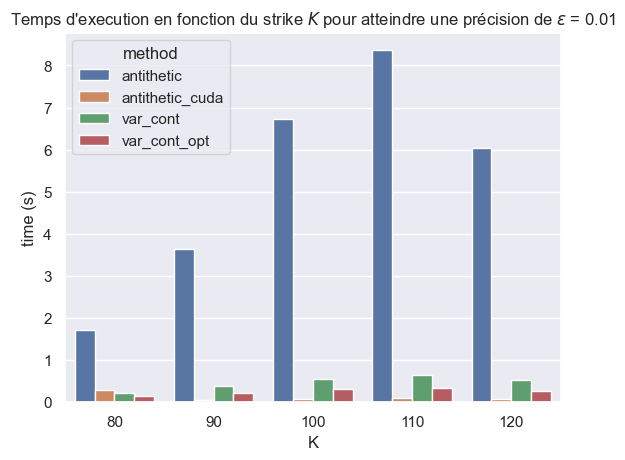

In [108]:
result = pd.concat([ result_antithetic, result_antithetic_mps, 
                     result_varcont, result_varcont_opt ])
ax = sns.barplot(data=result, x="K", y="time (s)", hue="method")
ax.set_title(fr"Temps d'execution en fonction du strike $K$ pour " + 
             fr"atteindre une précision de $\epsilon$ = {epsilon}");

### Combinaison des 2 méthodes

Il est possible de combiner plusieurs méthodes de réduction de variance.
Ici on fait une variable de contrôle (optimale) sur des variables
antithétiques.

In [109]:
def sampling_payoffs_antithetic_control_variate_opt(K, size, bs, rng): 
    Gn = rng.standard_normal((size, bs["d"]))
    payoffs_X1 = np.maximum(np.mean(phi(bs, Gn), axis=1) - K, 0) 
    payoffs_X2 = np.maximum(np.mean(phi(bs, -Gn), axis=1) - K, 0)
    payoffs_X = 0.5 * (payoffs_X1 + payoffs_X2)
    payoffs_Y1 = payoffs_control(bs, K, Gn)
    payoffs_Y2 = payoffs_control(bs, K, -Gn)
    payoffs_Y = 0.5 * (payoffs_Y1 + payoffs_Y2)

    cntxt["lambda_numerator"] += (payoffs_X * payoffs_Y).sum() 
    cntxt["lambda_denominator"] += (payoffs_Y**2).sum() 
    cntxt["lambda"] = cntxt["lambda_numerator"] / cntxt["lambda_denominator"]

    payoffs = payoffs_X - cntxt["lambda"] * payoffs_Y
    return bs["actualization"] * payoffs

In [110]:
name = "antithetic_var_cont_opt"
function = sampling_payoffs_antithetic_control_variate_opt

result = {} 
for K in [80, 90, 100, 110, 120]:
    cntxt = { "lambda_numerator": 0., "lambda_denominator": 1e-7 }
    result[K] = monte_carlo_adaptive(
        lambda size: function(K, size, bs, rng), 
        epsilon=epsilon, 
        batch_size=batch_size)
    result[K]["lambda"] = cntxt["lambda"]
result_df = pd.DataFrame(result).T
result_df["K"] = result_df.index
result_df["method"] = name 

result_antithetic_varcont_opt = result_df
result_antithetic_varcont_opt

Adaptive Monte Carlo: 80000it [00:00, 428014.23it/s, IC_size=0.00992, mean=27.8, var=0.512]
Adaptive Monte Carlo: 100000it [00:00, 417425.51it/s, IC_size=0.00901, mean=19.4, var=0.528]
Adaptive Monte Carlo: 100000it [00:00, 424307.82it/s, IC_size=0.00902, mean=12.3, var=0.53]
Adaptive Monte Carlo: 60000it [00:00, 413794.52it/s, IC_size=0.00884, mean=6.97, var=0.305]
Adaptive Monte Carlo: 100000it [00:00, 424733.62it/s, IC_size=0.00901, mean=3.55, var=0.528]


,mean,var,ci_size,samples_size,time (s),lambda,K,method
80,27.766779,0.511902,0.009916,80000.0,0.188013,0.972516,80,antithetic_var_cont_opt
90,19.398933,0.528058,0.009008,100000.0,0.240708,0.931822,90,antithetic_var_cont_opt
100,12.266264,0.529686,0.009022,100000.0,0.236727,0.952754,100,antithetic_var_cont_opt
110,6.965330,0.304993,0.008838,60000.0,0.146040,1.060539,110,antithetic_var_cont_opt
120,3.552981,0.528052,0.009008,100000.0,0.236170,1.140471,120,antithetic_var_cont_opt


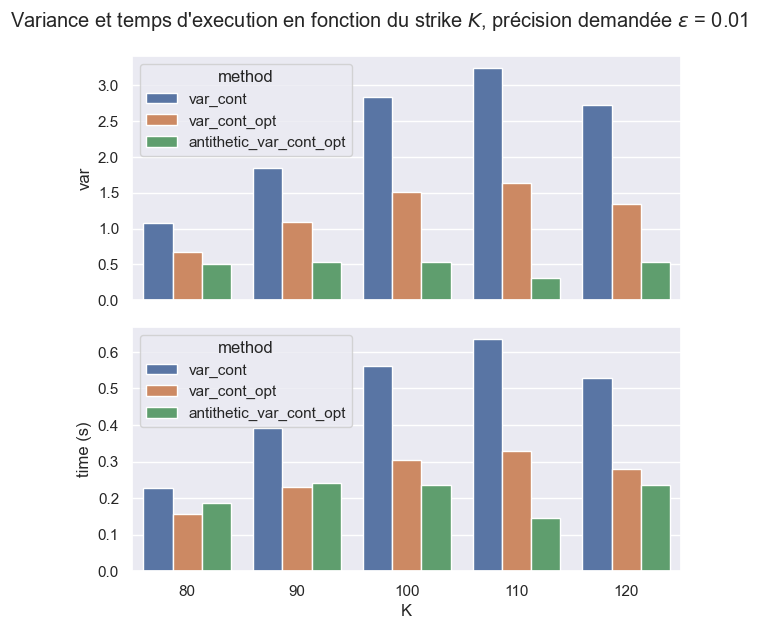

In [111]:
result = pd.concat([ result_varcont, result_varcont_opt, 
                     result_antithetic_varcont_opt ])
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6.4,6.4), 
                               sharex=True, layout="tight")
sns.barplot(data=result, x="K", y="var", hue="method", ax=ax1)
sns.barplot(data=result, x="K", y="time (s)", hue="method", ax=ax2)
fig.suptitle(fr"Variance et temps d'execution en fonction du strike $K$, "
             +fr"précision demandée $\epsilon$ = {epsilon}");